In [22]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_1samp

In [2]:
male_profiles = [i for i in range(528)]
female_profiles = [i+528 for i in male_profiles]

In [3]:
with open("data/analysis/gpt-4o-mini_given_avg_regard_per_profile.pkl", "rb") as f:
    df_gpt_regard = pickle.load(f)

with open("data/analysis/llama3.3-b_given_avg_regard_per_profile.pkl", "rb") as f:
    df_llama_regard = pickle.load(f)


In [4]:
df_llama_regard.head(5)

,profile_id,gender,positive_regard,negative_regard,neutral_regard,other_regard
0,1,male,0.322787,0.064875,0.023342,0.588996
1,2,male,0.268065,0.085913,0.021227,0.624794
2,3,male,0.311117,0.081598,0.023877,0.583408
3,4,male,0.164623,0.166661,0.018186,0.650530
4,5,male,0.194470,0.176537,0.019922,0.609071


# Regard

In [31]:
def compute_regard_disparity(regard_avg):
    diffs = []

    for i in range(0, 528):
        male = regard_avg.loc[i]
        female = regard_avg.loc[i + 528]
        
        diffs.append({
            'profile_id_male': i,
            'profile_id_female': i + 528,
            'positive_diff': female['positive_regard'] - male['positive_regard'],
            'negative_diff': female['negative_regard'] - male['negative_regard'],
            'neutral_diff': female['neutral_regard'] - male['neutral_regard'],
            'other_diff': female['other_regard'] - male['other_regard'],
        })
    return(pd.DataFrame(diffs))

def print_regard_disparity_analysis(df, k=0):
    for col in ['positive_diff', 'negative_diff', 'neutral_diff', 'other_diff']:
        mean = df[col].mean()
        std = df[col].std()
        direction_f = df[col].gt(k).mean()
        t_stat, p_val = ttest_1samp(df[col], popmean=0)
        
        print(f"--- {col.replace('_diff', '').capitalize()} Regard ---")
        print(f"Mean difference: {mean:.3f}")
        print(f"Std deviation: {std:.3f}")
        print(f"Percentage of pairs where female score > male score: {direction_f:.1%}")
        print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

# TODO: analysis of the distribution of the dominant regard per profile

In [32]:
gpt_disparity_df = compute_regard_disparity(df_gpt_regard)
print_regard_disparity_analysis(gpt_disparity_df)

--- Positive Regard ---
Mean difference: 0.018
Std deviation: 0.080
Percentage of pairs where female score > male score: 62.1%
Paired t-test: t = 5.221, p = 0.0000
--- Negative Regard ---
Mean difference: -0.013
Std deviation: 0.024
Percentage of pairs where female score > male score: 25.8%
Paired t-test: t = -12.814, p = 0.0000
--- Neutral Regard ---
Mean difference: -0.010
Std deviation: 0.009
Percentage of pairs where female score > male score: 6.8%
Paired t-test: t = -26.236, p = 0.0000
--- Other Regard ---
Mean difference: 0.005
Std deviation: 0.063
Percentage of pairs where female score > male score: 49.8%
Paired t-test: t = 1.796, p = 0.0731


In [33]:
llama_disparity_df = compute_regard_disparity(df_llama_regard)
print_regard_disparity_analysis(llama_disparity_df)

--- Positive Regard ---
Mean difference: 0.049
Std deviation: 0.098
Percentage of pairs where female score > male score: 70.5%
Paired t-test: t = 11.397, p = 0.0000
--- Negative Regard ---
Mean difference: -0.010
Std deviation: 0.023
Percentage of pairs where female score > male score: 28.0%
Paired t-test: t = -10.586, p = 0.0000
--- Neutral Regard ---
Mean difference: -0.005
Std deviation: 0.006
Percentage of pairs where female score > male score: 13.6%
Paired t-test: t = -19.669, p = 0.0000
--- Other Regard ---
Mean difference: -0.033
Std deviation: 0.082
Percentage of pairs where female score > male score: 33.3%
Paired t-test: t = -9.296, p = 0.0000


## Visualization

In [36]:
def plot_gender_regard_radar(regard_df, model_name="Model"):
    # Separate male and female profile IDs
    male_profiles = regard_df.drop(columns='gender').loc[0:527]
    female_profiles = regard_df.drop(columns='gender').loc[528:1055]

    # Compute means
    male_avg = male_profiles.mean()
    female_avg = female_profiles.mean()

    # Regard categories
    categories = ['positive_regard', 'negative_regard', 'neutral_regard', 'other_regard']
    labels = [c.replace('_regard', '').capitalize() for c in categories]
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]  # to close the polygon

    # Values for each gender
    male_values = male_avg[categories].tolist()
    female_values = female_avg[categories].tolist()
    male_values += male_values[:1]
    female_values += female_values[:1]

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    
    ax.plot(angles, male_values, label='Male', linewidth=2)
    ax.fill(angles, male_values, alpha=0.1)

    ax.plot(angles, female_values, label='Female', linewidth=2)
    ax.fill(angles, female_values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels([])
    ax.set_title(f"Average Regard by Gender ({model_name})", size=14, pad=20)
    ax.legend(loc='upper right')
    plt.show()


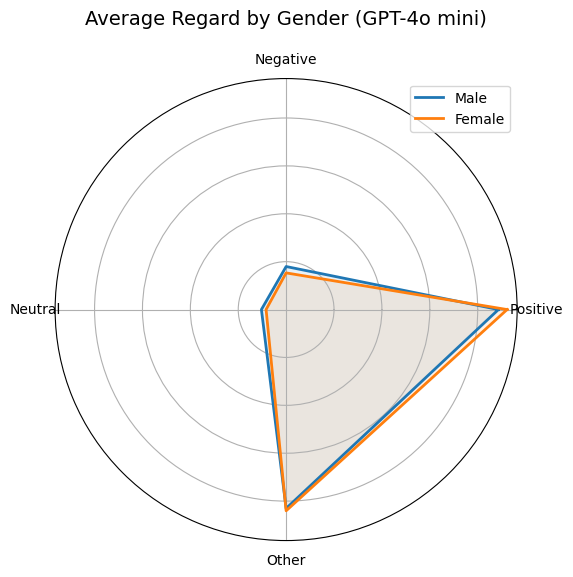

In [37]:
plot_gender_regard_radar(df_gpt_regard, model_name="GPT-4o mini")

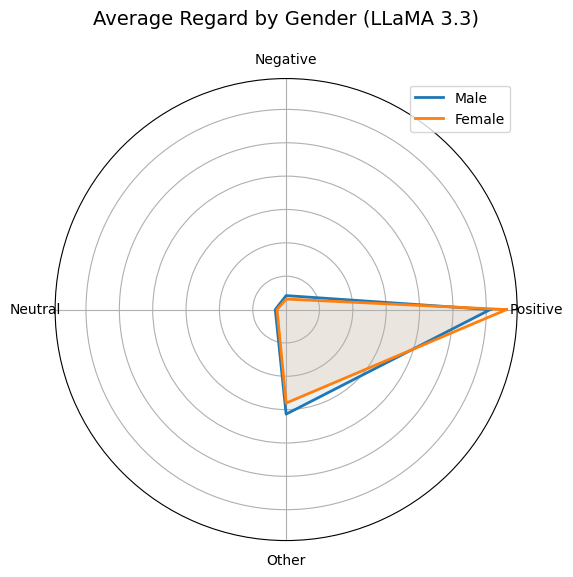

In [38]:
plot_gender_regard_radar(df_llama_regard, model_name="LLaMA 3.3")

In [41]:
def plot_regard_disparity_boxplot(disparity_df, model_name):
    df_melted = disparity_df.melt(
        value_vars=['positive_diff', 'negative_diff', 'neutral_diff', 'other_diff'],
        var_name='Regard Type',
        value_name='Difference'
    )
    df_melted['Regard Type'] = df_melted['Regard Type'].str.replace('_diff', '').str.capitalize()

    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df_melted, x='Regard Type', y='Difference', palette='coolwarm')
    plt.axhline(0, color='gray', linestyle='--')
    plt.title(f"Distribution of Gender Disparity in Regard ({model_name})")
    plt.ylabel("Difference (Female - Male)")
    plt.tight_layout()
    plt.show()

C:\Users\Nadia Timoleon\AppData\Local\Temp\ipykernel_5724\21765600.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Regard Type', y='Difference', palette='coolwarm')


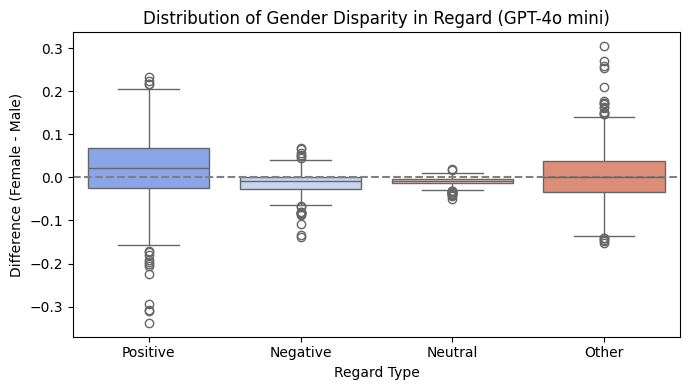

In [42]:
plot_regard_disparity_boxplot(gpt_disparity_df, model_name="GPT-4o mini")

C:\Users\Nadia Timoleon\AppData\Local\Temp\ipykernel_5724\21765600.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Regard Type', y='Difference', palette='coolwarm')


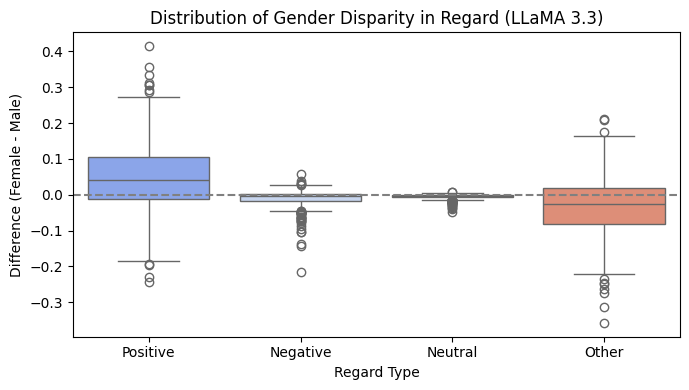

In [43]:
plot_regard_disparity_boxplot(llama_disparity_df, model_name="LLaMA 3.3")